# Train the Statistical Baseline: Multinomial Logistic Regression

This notebook establishes the benchmark *floor* for the career classifier project. The linear model ingests both the Gaussian noise-augmented intelligence features and the engineered K-Means cluster tags (Task 1). Production models (e.g., the Neural Network classifier or alternative classifiers) are expected to beat this baseline.

To keep the comparison honest, this notebook reuses the exact same preprocessing, noise augmentation, and stratified 80/20 split as the main training pipeline and reports the same Top-1 / Top-5 metrics.

In [1]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# Add parent directory to path so we can import preprocess
sys.path.append(os.path.abspath('..'))
from preprocess import add_noise, clean_raw_data, preprocess_data, rename_columns

DEFAULT_N_CLUSTERS = 8

## K-Means Helper Functions
Copied from `cluster_features` to provide self-contained feature engineering.

In [2]:
def fit_kmeans(X: pd.DataFrame, n_clusters: int = DEFAULT_N_CLUSTERS, random_state: int = 42) -> KMeans:
    """Fit a K-Means model on the (scaled, noise-augmented) feature matrix."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)
    return kmeans

def add_cluster_features(X: pd.DataFrame, kmeans: KMeans) -> pd.DataFrame:
    """Append one-hot encoded K-Means cluster tags to the feature matrix."""
    labels = kmeans.predict(X)
    n_clusters = kmeans.n_clusters

    cluster_cols = [f'cluster_{i}' for i in range(n_clusters)]
    one_hot = pd.DataFrame(
        np.eye(n_clusters, dtype=float)[labels],
        columns=cluster_cols,
        index=X.index,
    )
    return pd.concat([X, one_hot], axis=1)

## Pipeline Helper Functions

In [3]:
def load_raw_dataset(df: pd.DataFrame):
    if 'Job profession' in df.columns:
        df = rename_columns(df)

    if 'job_profession' not in df.columns:
        raise ValueError("Expected 'job_profession' or 'Job profession' column in raw dataset")

    return preprocess_data(df)

def train_model(X_train, y_train) -> LogisticRegression:
    # Multinomial logistic regression
    model = LogisticRegression(
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
    )
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    top_1_acc = accuracy_score(y_test, y_pred)
    top_5_indices = np.argsort(y_probs, axis=1)[:, -5:][:, ::-1]
    top_5_hits = [y_test[i] in top_5_indices[i] for i in range(len(y_test))]
    top_5_acc = np.mean(top_5_hits)

    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    return top_1_acc, top_5_acc, report

def save_artifact(obj, path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(obj, path)

## Run Training and Evaluation Pipeline

In [4]:
# Input and output configuration (relative to notebook directory)
input_csv = '../dataset/dataset_skill_predictor.csv'
model_output = '../models/career_baseline_logreg.joblib'
n_clusters = DEFAULT_N_CLUSTERS

# Load and clean
df = pd.read_csv(input_csv)
df = clean_raw_data(df)
X, y, label_encoder = load_raw_dataset(df)

# Gaussian noise augmentation
X_noisy = add_noise(X, noise_level=0.06)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42, stratify=y
)

# Fit K-Means on train split and append cluster tags
kmeans = fit_kmeans(X_train, n_clusters=n_clusters, random_state=42)
X_train_aug = add_cluster_features(X_train, kmeans)
X_test_aug = add_cluster_features(X_test, kmeans)

print(f"Baseline features: {X_train_aug.shape[1]} "
      f"({X_train.shape[1]} intelligence + {n_clusters} cluster tags)")

# Train baseline model
model = train_model(X_train_aug, y_train)

# Evaluate
top_1_acc, top_5_acc, report = evaluate_model(model, X_test_aug, y_test)

print(f"\n=== Multinomial Logistic Regression Baseline ===")
print(f"Top-1 Accuracy: {top_1_acc * 100:.2f}%")
print(f"Top-5 Accuracy: {top_5_acc * 100:.2f}%")
print(f"Macro Precision: {report['macro avg']['precision'] * 100:.2f}%")
print(f"Macro Recall:    {report['macro avg']['recall'] * 100:.2f}%")
print(f"Macro F1-Score:  {report['macro avg']['f1-score'] * 100:.2f}%")

# Save artifacts
model_dir = os.path.dirname(model_output)
save_artifact(model, model_output)

kmeans_output = os.path.join(model_dir, 'career_baseline_kmeans.joblib')
encoder_output = os.path.join(model_dir, 'career_baseline_label_encoder.joblib')
save_artifact(kmeans, kmeans_output)
save_artifact(label_encoder, encoder_output)

print(f"\nBaseline model saved to: {model_output}")
print(f"K-Means tagger saved to: {kmeans_output}")
print(f"Label encoder saved to: {encoder_output}")

Baseline features: 16 (8 intelligence + 8 cluster tags)



=== Multinomial Logistic Regression Baseline ===
Top-1 Accuracy: 78.61%
Top-5 Accuracy: 97.08%
Macro Precision: 79.44%
Macro Recall:    78.61%
Macro F1-Score:  77.21%

Baseline model saved to: ../models/career_baseline_logreg.joblib
K-Means tagger saved to: ../models\career_baseline_kmeans.joblib
Label encoder saved to: ../models\career_baseline_label_encoder.joblib


## Added experiment section: Cross-validation, GridSearch, and visualizations

This section validates the multinomial logistic-regression baseline with cross-validation and GridSearch. The grid focuses on `C`, the inverse regularization strength. Smaller `C` means stronger regularization, which can help a linear model generalize when cluster tags add extra features.


In [5]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

VIS_DIR = './visualizations'
os.makedirs(VIS_DIR, exist_ok=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

baseline_cv_scores = cross_val_score(
    LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42),
    X_train_aug,
    y_train,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
print(f"Baseline Logistic Regression 3-fold CV accuracy: {baseline_cv_scores.mean() * 100:.2f}% ± {baseline_cv_scores.std() * 100:.2f}%")

logreg_grid = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=3000, random_state=42),
    param_grid={'C': [0.1, 1.0, 10.0]},
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
logreg_grid.fit(X_train_aug, y_train)
best_logreg = logreg_grid.best_estimator_
best_logreg_top1, best_logreg_top5, best_logreg_report = evaluate_model(best_logreg, X_test_aug, y_test)

print("Best Logistic Regression parameters:", logreg_grid.best_params_)
print(f"Best Logistic Regression Top-1 Accuracy: {best_logreg_top1 * 100:.2f}%")
print(f"Best Logistic Regression Top-5 Accuracy: {best_logreg_top5 * 100:.2f}%")
print(f"Best Logistic Regression Macro Precision: {best_logreg_report['macro avg']['precision'] * 100:.2f}%")
print(f"Best Logistic Regression Macro Recall:    {best_logreg_report['macro avg']['recall'] * 100:.2f}%")
print(f"Best Logistic Regression Macro F1-Score:  {best_logreg_report['macro avg']['f1-score'] * 100:.2f}%")


Baseline Logistic Regression 3-fold CV accuracy: 73.54% ± 1.03%
Fitting 3 folds for each of 3 candidates, totalling 9 fits


Best Logistic Regression parameters: {'C': 10.0}
Best Logistic Regression Top-1 Accuracy: 82.36%
Best Logistic Regression Top-5 Accuracy: 99.31%
Best Logistic Regression Macro Precision: 82.23%
Best Logistic Regression Macro Recall:    82.36%
Best Logistic Regression Macro F1-Score:  81.67%


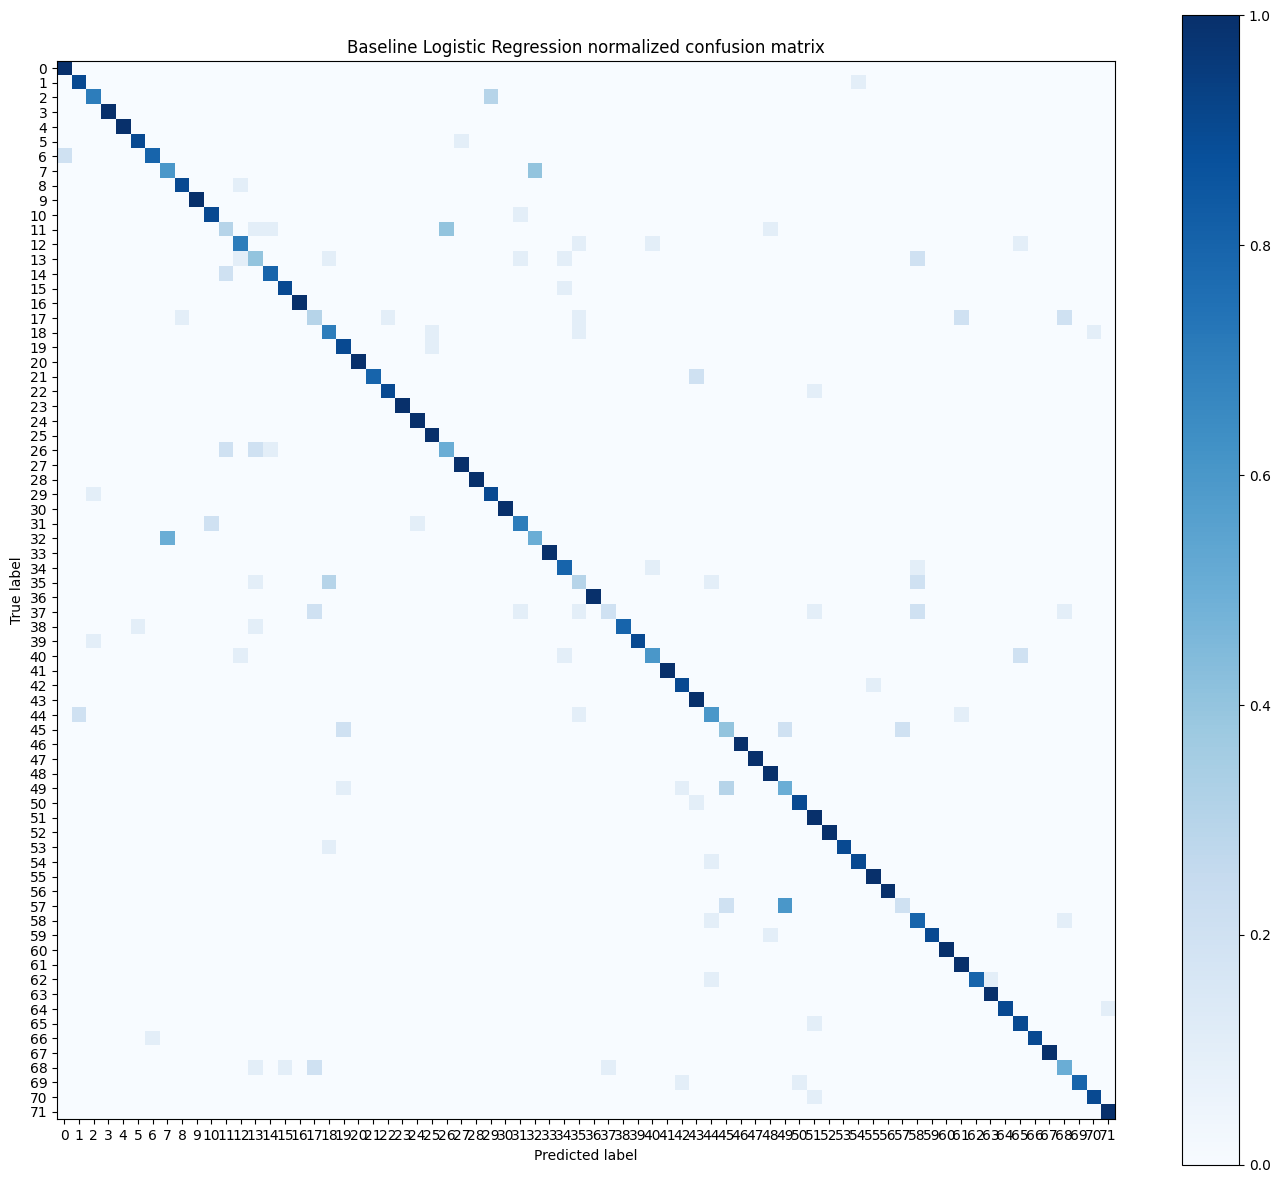

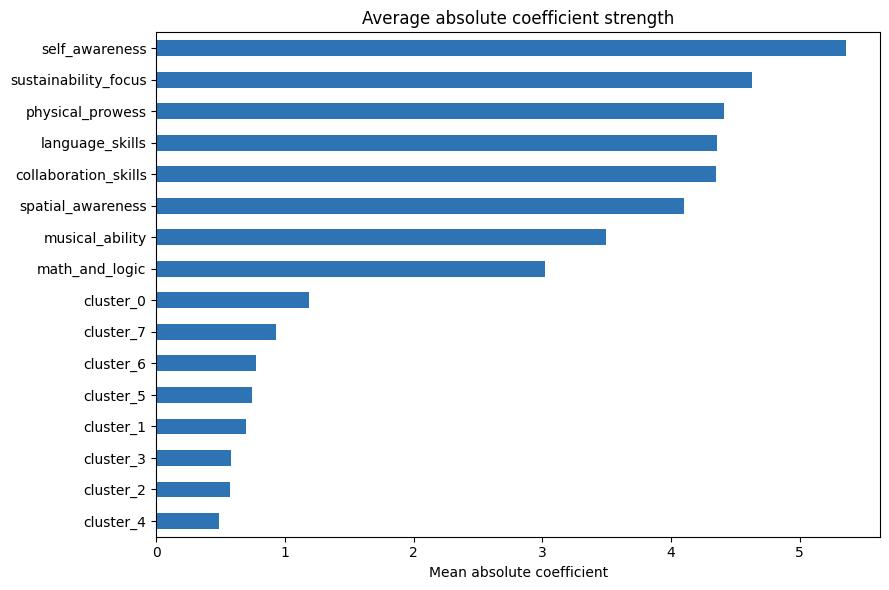

In [6]:
best_logreg_pred = best_logreg.predict(X_test_aug)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_logreg_pred,
    normalize='true',
    include_values=False,
    cmap='Blues',
    ax=ax
)
ax.set_title('Baseline Logistic Regression normalized confusion matrix')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'baseline_logistic_regression_confusion_matrix.png'), dpi=180)
plt.show()

coef_strength = pd.Series(
    np.abs(best_logreg.coef_).mean(axis=0),
    index=X_train_aug.columns
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
coef_strength.plot(kind='barh', ax=ax, color='#2E74B5')
ax.set_title('Average absolute coefficient strength')
ax.set_xlabel('Mean absolute coefficient')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'baseline_logistic_regression_coefficients.png'), dpi=180)
plt.show()
